# A1 Training Curves: Per-Class View
This notebook trains the A1 configuration (MLP + Autoencoder Features) capturing **per-class F1 scores**.
This allows us to visualize how minority vs majority classes learn over time depending on the imbalance strategy.


In [1]:
import os, sys, gc, logging, copy, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import precision_recall_fscore_support

PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import SEED, set_global_seed
from src.utils.paths import get_reduced_dir, ensure_dir, get_experiment_dir, get_experiment_output_dir
from src.data import CLASS_NAMES, load_labels
from src.data.splits import load_splits
from src.models.mlp import MLPClassifier
from src.data.smoteenn_resampling import apply_smoteenn_to_reduced_features
from src.training.class_balanced_focal import make_cb_focal_loss
from src.training.weighted_ce import make_weighted_ce_loss

NUM_CLASSES = len(CLASS_NAMES)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using {device}")


Using cuda


In [2]:
idx_train, idx_val, idx_test = load_splits()
try:
    y_full = load_labels()
except FileNotFoundError:
    from src.data import load_raw_dataset
    _, y_full = load_raw_dataset()
y_idx = np.argmax(y_full, axis=1) if y_full.ndim == 2 else y_full
y_train, y_val, y_test = y_idx[idx_train], y_idx[idx_val], y_idx[idx_test]

red_dir_ae = get_reduced_dir() / "autoencoder"
features_ae = {
    'train': np.load(red_dir_ae / "train.npy").astype(np.float32),
    'val': np.load(red_dir_ae / "val.npy").astype(np.float32),
    'test': np.load(red_dir_ae / "test.npy").astype(np.float32)
}


In [3]:
def train_a1(imb_method):
    set_global_seed(SEED)
    X_tr, X_vl, X_ts = features_ae['train'], features_ae['val'], features_ae['test']
    input_dim = X_tr.shape[1]
    cond_name = f"A1_autoencoder_{imb_method}_per_class_curves"
    
    exp_dir = ensure_dir(get_experiment_dir(cond_name))
    ckpt_dir = ensure_dir(get_experiment_output_dir(cond_name, checkpoints=True))
    ckpt_path = ckpt_dir / "model.pt"
    history_path = ckpt_dir / "history.json"
    
    y_train_local = y_train.copy()
    if imb_method == 'SMOTEENN':
        X_tr, y_train_local = apply_smoteenn_to_reduced_features(X_tr, y_train_local)
        
    if imb_method == 'Focal':
        criterion = make_cb_focal_loss(y_train_local, NUM_CLASSES, device=device)
    elif imb_method == 'WeightedCE':
        criterion = make_weighted_ce_loss(y_train_local, NUM_CLASSES, device=device)
    else:
        criterion = torch.nn.CrossEntropyLoss()
        
    model = MLPClassifier(input_dim=input_dim, num_classes=NUM_CLASSES, hidden_dims=[1024, 512, 256, 128], dropout=0.2).to(device)
    lr, bs, eps = 1e-3, 256, 80
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    
    best_val_f1 = -1
    patience = 20
    epochs_no_improve = 0
    
    history = {'train_loss': [], 'val_f1_weighted': [], 'val_f1_per_class': []}
    
    best_wts = copy.deepcopy(model.state_dict())
    
    for ep in range(eps):
        model.train()
        perm = np.random.permutation(len(X_tr))
        total_loss = 0
        nb = 0
        for start in range(0, len(X_tr), bs):
            idx = perm[start:start+bs]
            bx = torch.from_numpy(X_tr[idx]).float().to(device)
            by = torch.from_numpy(y_train_local[idx]).long().to(device)
            
            opt.zero_grad()
            logits = model(bx)
            loss = criterion(logits, by)
            loss.backward()
            opt.step()
            
            total_loss += loss.item()
            nb += 1
        
        epoch_loss = total_loss / nb
        
        model.eval()
        with torch.no_grad():
            vl_x = torch.from_numpy(X_vl).float()
            vl_logits = []
            for idx_v in range(0, len(vl_x), bs*2):
                vl_logits.append(model(vl_x[idx_v:idx_v+bs*2].to(device)).cpu())
            vl_logits = torch.cat(vl_logits)
            val_preds = vl_logits.argmax(dim=1).numpy()
            
            _, _, f1_per_class, _ = precision_recall_fscore_support(y_val, val_preds, labels=list(range(NUM_CLASSES)), average=None, zero_division=0)
            _, _, f1_weighted, _  = precision_recall_fscore_support(y_val, val_preds, labels=list(range(NUM_CLASSES)), average='weighted', zero_division=0)
        
        history['train_loss'].append(epoch_loss)
        history['val_f1_weighted'].append(f1_weighted)
        history['val_f1_per_class'].append(f1_per_class.tolist())
        
        if f1_weighted > best_val_f1:
            best_val_f1 = f1_weighted
            best_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            torch.save({'model_state': model.state_dict()}, ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break
    
    with open(history_path, 'w') as f:
        json.dump(history, f)
    
    return history


In [4]:
histories = {}
for imb in ['None', 'WeightedCE', 'Focal', 'SMOTEENN']:
    print(f"\nTraining A1 with {imb}...")
    histories[imb] = train_a1(imb)



Training A1 with None...

Training A1 with WeightedCE...

Training A1 with Focal...

Training A1 with SMOTEENN...


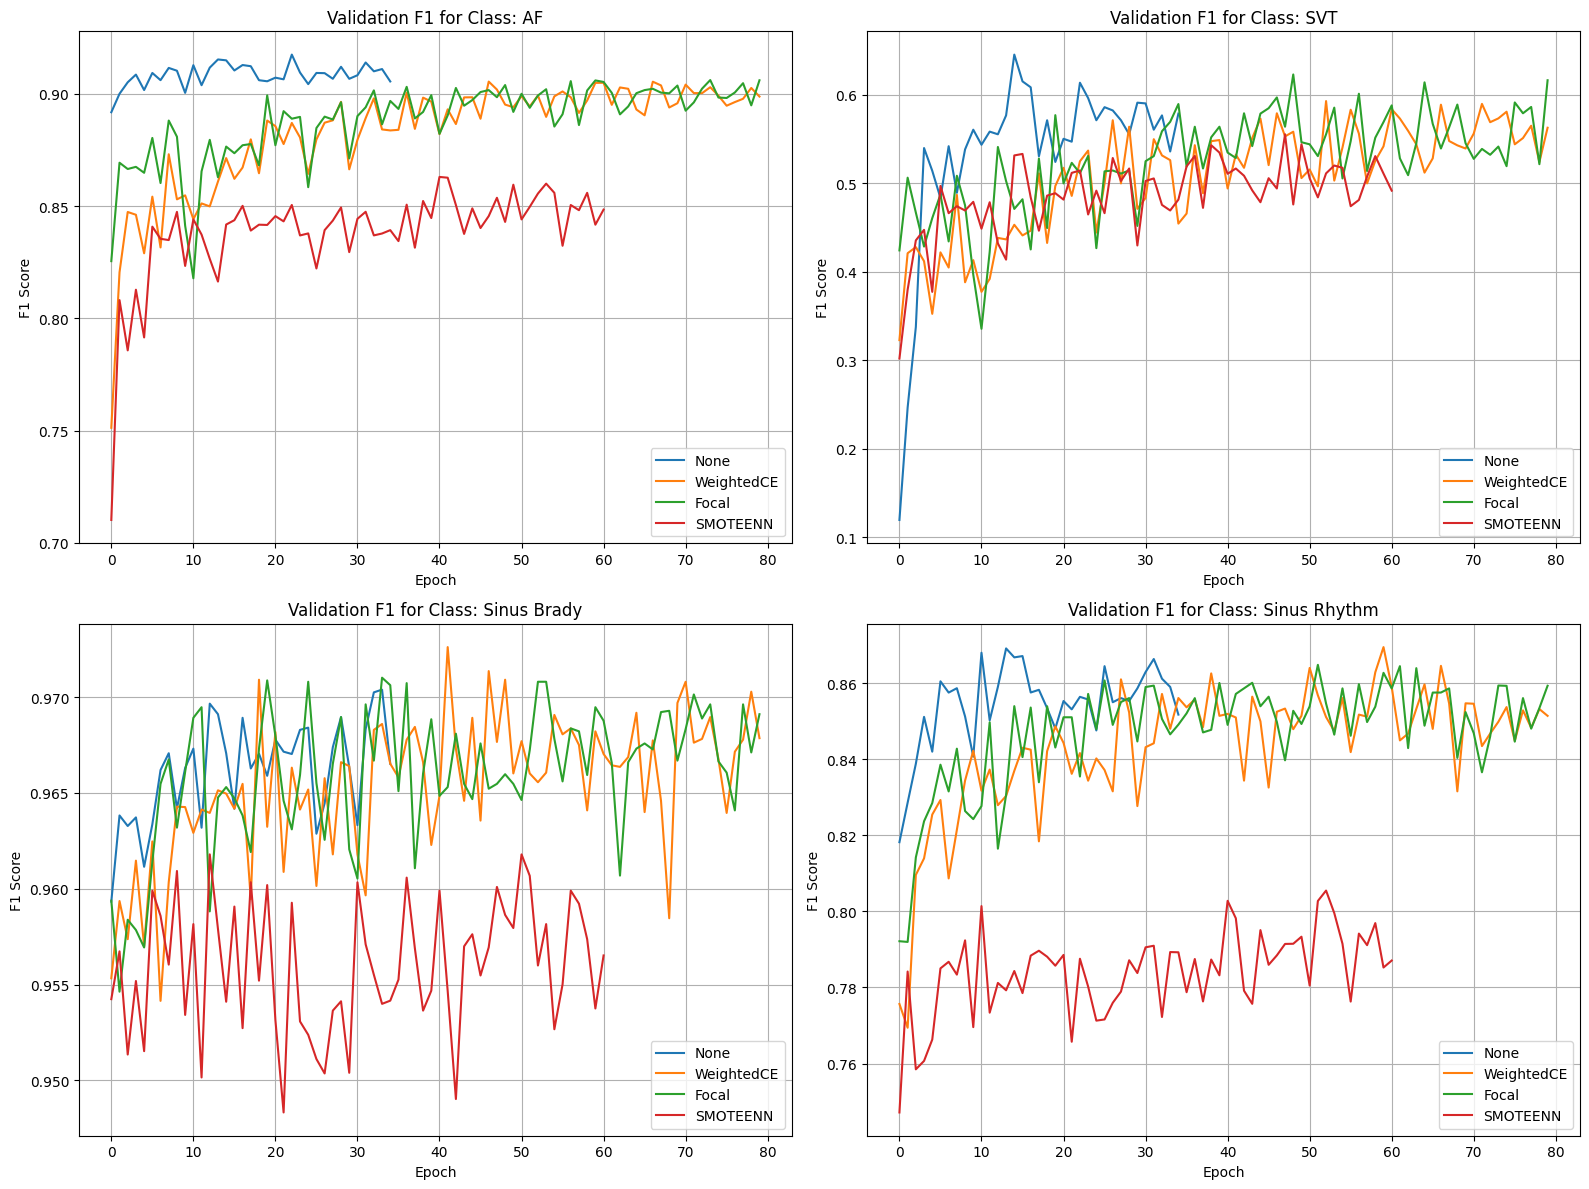

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for class_idx, class_name in enumerate(CLASS_NAMES):
    ax = axes[class_idx]
    for imb, hist in histories.items():
        # Extract the F1 curve specifically for this class
        class_f1_curve = [epoch_f1s[class_idx] for epoch_f1s in hist['val_f1_per_class']]
        ax.plot(class_f1_curve, label=f'{imb}')
    
    ax.set_title(f'Validation F1 for Class: {class_name}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('F1 Score')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


In [7]:
import json
import pandas as pd
from pathlib import Path
from src.utils.paths import get_experiment_output_dir
from src.data import CLASS_NAMES

# 1. Export Overall Histories (Notebook 12)
overall_rows = []
for imb in ['None', 'WeightedCE', 'Focal', 'SMOTEENN']:
    cond_name = f"A1_autoencoder_{imb}_curves_experiment"
    hist_path = get_experiment_output_dir(cond_name, checkpoints=True) / "history.json"
    
    if hist_path.exists():
        with open(hist_path, 'r') as f:
            hist = json.load(f)
        for ep in range(len(hist['train_loss'])):
            overall_rows.append({
                'Imbalance_Method': imb,
                'Epoch': ep,
                'Train_Loss': hist['train_loss'][ep],
                'Validation_Weighted_F1': hist['val_f1'][ep]
            })

if overall_rows:
    pd.DataFrame(overall_rows).to_csv("a1_overall_training_histories.csv", index=False)
    print("Exported 'a1_overall_training_histories.csv'")
else:
    print("Could not find Notebook 12 overall history files (has it been trained yet?)")


# 2. Export Per-Class Histories (Notebook 13)
per_class_rows = []
for imb in ['None', 'WeightedCE', 'Focal', 'SMOTEENN']:
    cond_name = f"A1_autoencoder_{imb}_per_class_curves"
    hist_path = get_experiment_output_dir(cond_name, checkpoints=True) / "history.json"
    
    if hist_path.exists():
        with open(hist_path, 'r') as f:
            hist = json.load(f)
        for ep in range(len(hist['train_loss'])):
            row = {
                'Imbalance_Method': imb,
                'Epoch': ep,
                'Train_Loss': hist['train_loss'][ep],
                'Validation_Weighted_F1': hist['val_f1_weighted'][ep]
            }
            # Extract each specific class F1 per epoch
            for class_idx, class_name in enumerate(CLASS_NAMES):
                row[f'{class_name}_F1'] = hist['val_f1_per_class'][ep][class_idx]
            
            per_class_rows.append(row)

if per_class_rows:
    pd.DataFrame(per_class_rows).to_csv("a1_per_class_training_histories.csv", index=False)
    print("Exported 'a1_per_class_training_histories.csv'")
else:
    print("Could not find Notebook 13 per-class history files (has it been trained yet?)")


Could not find Notebook 12 overall history files (has it been trained yet?)
Exported 'a1_per_class_training_histories.csv'
